## **1.IMPORT ESSENTIAL LIBRARIES**

This is a dataset on ai impact on jobs and layoff risk across industries .
Objective is to analyze the relationship between ai adoptions , task automation , workforce characterstics and employment risk.
building classifications model to predict layoff and risk

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score

## **2.Data loading and validation**

In [2]:
#LOADE DATASET 
url=("https://raw.githubusercontent.com/mrrendex2006/machine-learning-from-scratch/refs/heads/main/dataset%20for%20practice/Ai%20impact%20on%20job/ai-impact-jobs-layoff-risk-dataset.csv")

# df=pd.read_csv('ai-impact-jobs-layoff-risk-dataset.csv')
df=pd.read_csv(url)
df.head()

,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium


In [ ]:
print(f"Shape of the dataset:{df.shape}")

Shape of the dataset:(20000, 16)


In [4]:
print("-------Datatypes & non null counts-------")
df.info()

print("\n")
print("====symmery of the dataset=====")
df.describe()


-------Datatypes & non null counts-------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         20000 non-null  int64 
 1   Education_Level             20000 non-null  object
 2   Years_of_Experience         20000 non-null  int64 
 3   Industry                    20000 non-null  object
 4   Job_Role                    20000 non-null  object
 5   Company_Size                20000 non-null  object
 6   Job_Level                   20000 non-null  object
 7   Routine_Task_Percentage     20000 non-null  int64 
 8   Creativity_Requirement      20000 non-null  int64 
 9   Human_Interaction_Level     20000 non-null  int64 
 10  AI_Adoption_Level           20000 non-null  object
 11  Number_of_AI_Tools_Used     20000 non-null  int64 
 12  AI_Usage_Hours_Per_Week     20000 non-null  int64 
 13  Task

,Age,Years_of_Experience,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.00000,20000.000000
mean,40.361500,7.265500,51.885500,47.786700,60.055000,2.460350,6.77395,37.22895,12.621400
std,11.526333,4.720606,24.437808,26.100482,22.267801,2.097486,6.08637,19.99512,13.552647
min,21.000000,0.000000,10.000000,0.000000,20.000000,0.000000,0.00000,4.00000,0.000000
25%,30.000000,4.000000,31.000000,27.000000,41.000000,1.000000,2.00000,21.00000,4.000000
50%,40.000000,7.000000,52.000000,48.000000,62.000000,2.000000,5.00000,35.00000,8.000000
75%,50.000000,11.000000,73.000000,69.000000,79.000000,4.000000,10.00000,51.00000,18.000000
max,60.000000,32.000000,94.000000,100.000000,99.000000,10.000000,30.00000,93.00000,79.000000


In [5]:
print(f"Missing value in dataset")
df.isnull().sum()

Missing value in dataset


,0
Age,0
Education_Level,0
Years_of_Experience,0
Industry,0
Job_Role,0
Company_Size,0
Job_Level,0
Routine_Task_Percentage,0
Creativity_Requirement,0
Human_Interaction_Level,0


In [6]:
corr_matrix=df.corr(numeric_only=True) # this will work as it drops columns have non numeric data
print(corr_matrix)


                                 Age  Years_of_Experience  \
Age                         1.000000             0.381019   
Years_of_Experience         0.381019             1.000000   
Routine_Task_Percentage     0.000242            -0.003817   
Creativity_Requirement      0.000530             0.004944   
Human_Interaction_Level     0.002161             0.014545   
Number_of_AI_Tools_Used     0.003540            -0.003431   
AI_Usage_Hours_Per_Week     0.004635            -0.003771   
Tasks_Automated_Percentage -0.000609            -0.004052   
AI_Training_Hours          -0.001468            -0.002974   

                            Routine_Task_Percentage  Creativity_Requirement  \
Age                                        0.000242                0.000530   
Years_of_Experience                       -0.003817                0.004944   
Routine_Task_Percentage                    1.000000               -0.927758   
Creativity_Requirement                    -0.927758                1.0000

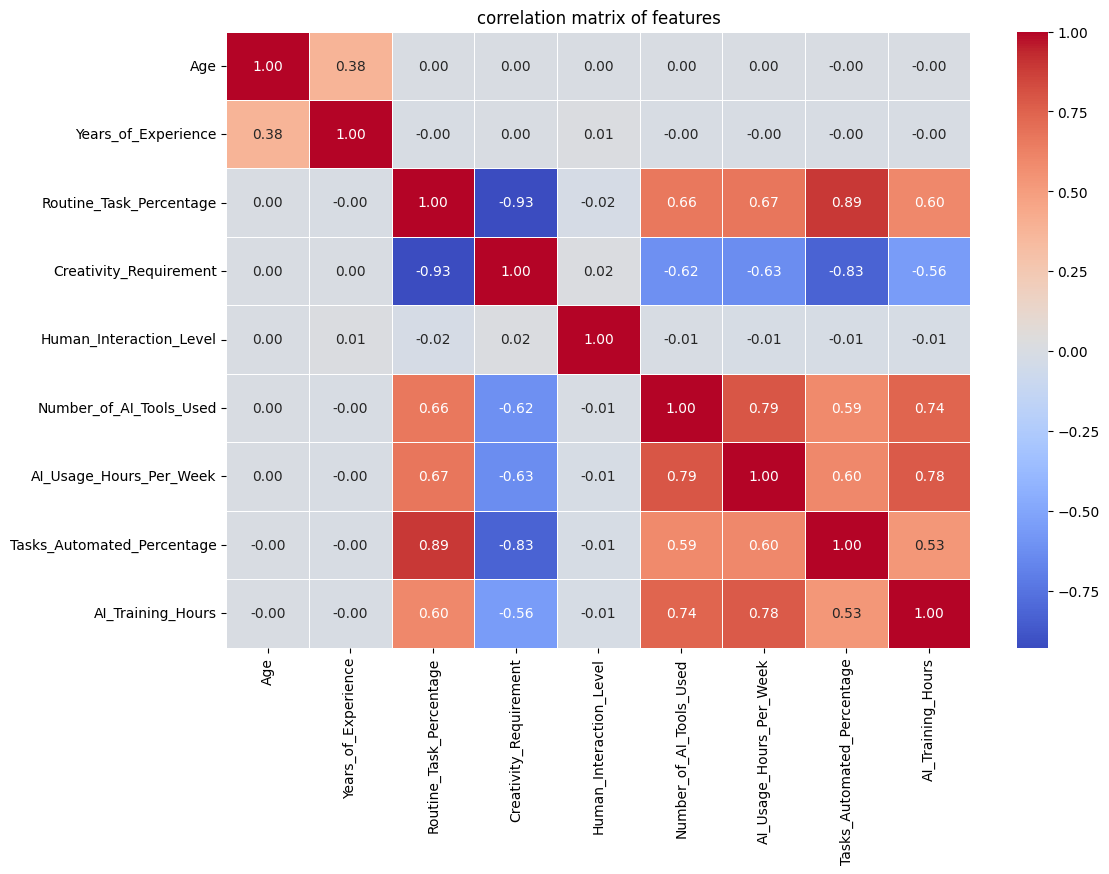

In [7]:
#ploting heatmap ( visulisatio of correlations matrix )
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('correlation matrix of features')
plt.show()


This heatmap show correlation of features. those features that correlates well(correlation is near 1) has to be dropes as they might leak data to our model and make it overfit to the data 

## **Data cleaning and prepatation**

In [8]:
#droping these columns as they likely may cause overfiting because of there high correlations 
features_to_drop=['Creativity_Requirement','Tasks_Automated_Percentage']
df=df.drop(columns=features_to_drop,errors='ignore')


In [9]:

#before spliting and asigning layoff column to y we need to change string int int 
target_mapping={'Low':0,'Medium':1,'High':2}
df['Layoff_Risk']=df['Layoff_Risk'].map(target_mapping)
y=df['Layoff_Risk']
x_raw=df.drop(columns='Layoff_Risk',errors='ignore')

In [10]:
print(df['Layoff_Risk'].unique())
print(df['Layoff_Risk'].isna().sum())


[2 0 1]
0


In [11]:
#encodeling the features have dtype string 
df_encoded=pd.get_dummies(x_raw,drop_first=True)
df_encoded.head()
print(df_encoded.columns.tolist())
X=df_encoded

['Age', 'Years_of_Experience', 'Routine_Task_Percentage', 'Human_Interaction_Level', 'Number_of_AI_Tools_Used', 'AI_Usage_Hours_Per_Week', 'AI_Training_Hours', 'Education_Level_High School', "Education_Level_Master's", 'Education_Level_PhD', 'Industry_Finance', 'Industry_Healthcare', 'Industry_IT', 'Industry_Logistics', 'Industry_Manufacturing', 'Industry_Retail', 'Industry_Telecom', 'Job_Role_Accountant', 'Job_Role_Auditor', 'Job_Role_Data Analyst', 'Job_Role_Dispatcher', 'Job_Role_Financial Analyst', 'Job_Role_Health Analyst', 'Job_Role_Inventory Analyst', 'Job_Role_ML Engineer', 'Job_Role_Medical Assistant', 'Job_Role_Network Engineer', 'Job_Role_Nurse', 'Job_Role_Operations Analyst', 'Job_Role_Operator', 'Job_Role_Production Supervisor', 'Job_Role_Quality Engineer', 'Job_Role_Research Assistant', 'Job_Role_Sales Associate', 'Job_Role_Software Engineer', 'Job_Role_Store Manager', 'Job_Role_Supply Chain Analyst', 'Job_Role_Support Specialist', 'Job_Role_Teacher', 'Job_Role_Warehouse 

In [12]:

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(X_train)
x_test=scaler.transform(X_test)

In [14]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

y_pred=model.predict(x_test)

In [15]:

print("model accuracy : ",accuracy_score(y_test,y_pred))
print("\nDetailed classsification report: \n",classification_report(y_test,y_pred))

model accuracy :  0.89

Detailed classsification report: 
               precision    recall  f1-score   support

           0       0.92      0.93      0.92      1296
           1       0.83      0.84      0.83      1329
           2       0.91      0.91      0.91      1375

    accuracy                           0.89      4000
   macro avg       0.89      0.89      0.89      4000
weighted avg       0.89      0.89      0.89      4000



In [16]:
cofficients=model.coef_[0]

feature_name=X.columns

importance_df=pd.DataFrame({'Feature':feature_name,'Weight':cofficients}).sort_values(by='Weight',ascending=False)
print(importance_df)

                           Feature    Weight
43                Job_Level_Senior  3.348987
42                   Job_Level_Mid  1.684802
3          Human_Interaction_Level  1.438763
8         Education_Level_Master's  1.181145
1              Years_of_Experience  1.047959
9              Education_Level_PhD  0.948826
6                AI_Training_Hours  0.740962
41              Company_Size_Small  0.053406
0                              Age  0.048311
4          Number_of_AI_Tools_Used  0.023139
32     Job_Role_Research Assistant  0.013593
40             Company_Size_Medium  0.003612
5          AI_Usage_Hours_Per_Week -0.011260
22         Job_Role_Health Analyst -0.027943
38                Job_Role_Teacher -0.033740
25      Job_Role_Medical Assistant -0.057025
27                  Job_Role_Nurse -0.085037
11             Industry_Healthcare -0.103770
44           AI_Adoption_Level_Low -0.106152
45        AI_Adoption_Level_Medium -0.134282
24            Job_Role_ML Engineer -0.171999
19        

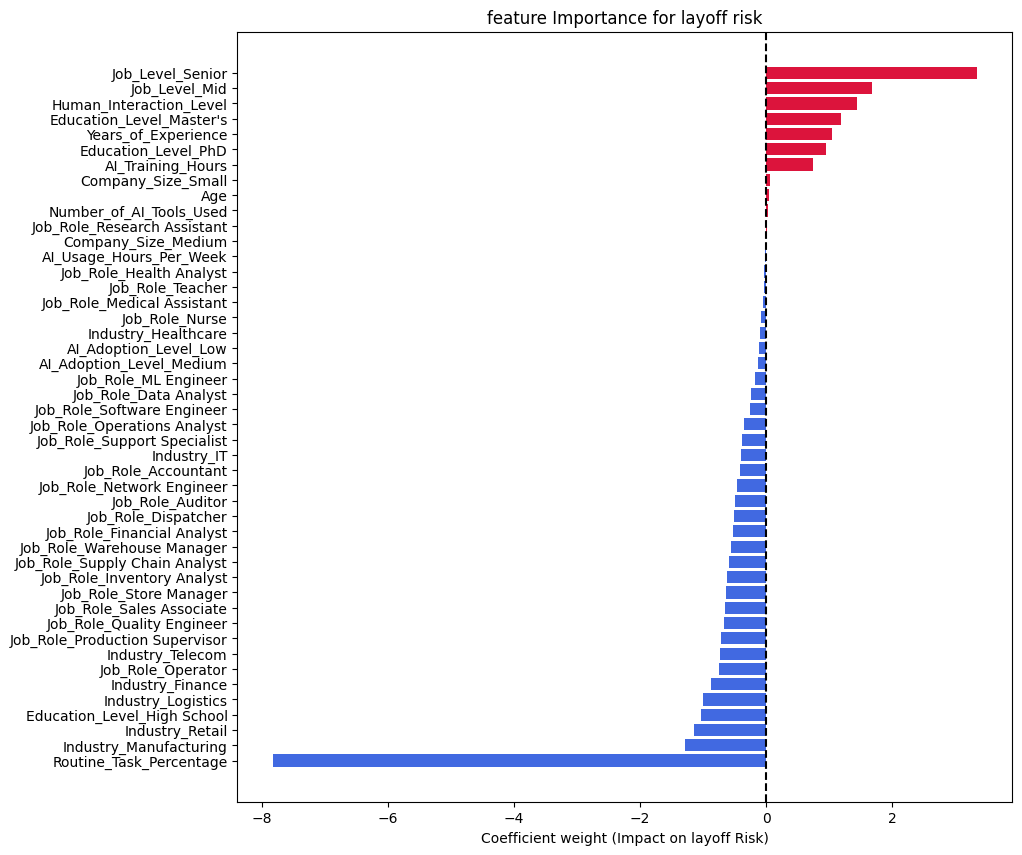

In [17]:
plt.figure(figsize=(10,10))
colors=['crimson'if w>0 else 'royalblue' for w in importance_df['Weight']]
plt.barh(importance_df['Feature'],importance_df['Weight'],color=colors)
plt.axvline(0, color='black',linestyle='--')
plt.xlabel('Coefficient weight (Impact on layoff Risk)')
plt.title('feature Importance for layoff risk')
plt.gca().invert_yaxis()
plt.show()

In [18]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(x_train,y_train)

dt_pred=dt.predict(x_test)
print("-----------decision tree performance-------------")
print("Acsuracy:",accuracy_score(y_test,dt_pred))


-----------decision tree performance-------------
Acsuracy: 0.74925


In [19]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier()
rf_model.fit(x_train,y_train)

rf_pred=rf_model.predict(x_test)
print("----------Random forest Performance--------------")
print("Accuracy : ",accuracy_score(y_test,rf_pred))
print("Classification report :",classification_report(y_test,rf_pred))

----------Random forest Performance--------------
Accuracy :  0.854
Classification report :               precision    recall  f1-score   support

           0       0.91      0.90      0.90      1296
           1       0.78      0.79      0.78      1329
           2       0.88      0.87      0.88      1375

    accuracy                           0.85      4000
   macro avg       0.85      0.85      0.85      4000
weighted avg       0.85      0.85      0.85      4000



In [20]:
#here comes a major step in ml . hyperparameter turing : it is doing changes parameters to improve our model accuracy
# using grand search cv
from sklearn.model_selection import GridSearchCV

param_gram={'n_estimators':[50,100,200], 'max_depth':[None,10,20],'min_samples_split':[2,5,10]} 
# n estimators is no of trees in the forest,max depth of tree,minimum sample to split a node 
rf_base=RandomForestClassifier(random_state=42)

grid_search=GridSearchCV(estimator=rf_base, param_grid=param_gram, cv=2, scoring='accuracy',n_jobs=-1)

In [21]:
print("Searching for the best  hyperparameter ...(this might take a few moments)")
grid_search.fit(x_train,y_train)
print("\nBest parameter Found:",grid_search.best_params_)

Searching for the best  hyperparameter ...(this might take a few moments)

Best parameter Found: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


In [22]:
best_rf_model=grid_search.best_estimator_
grid_pred=best_rf_model.predict(x_test)

print("\n---------------tuned Random Forest Performance--------------------")
print("new Accuracy:",accuracy_score(y_test,grid_pred))
print("new Classsinfication Report: ",classification_report(y_test,grid_pred))


---------------tuned Random Forest Performance--------------------
new Accuracy: 0.8535
new Classsinfication Report:                precision    recall  f1-score   support

           0       0.91      0.90      0.90      1296
           1       0.77      0.79      0.78      1329
           2       0.88      0.88      0.88      1375

    accuracy                           0.85      4000
   macro avg       0.85      0.85      0.85      4000
weighted avg       0.85      0.85      0.85      4000



/tmp/ipykernel_2280/2563879848.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance',y='Feature',data=importance_df.head(10),palette='viridis')


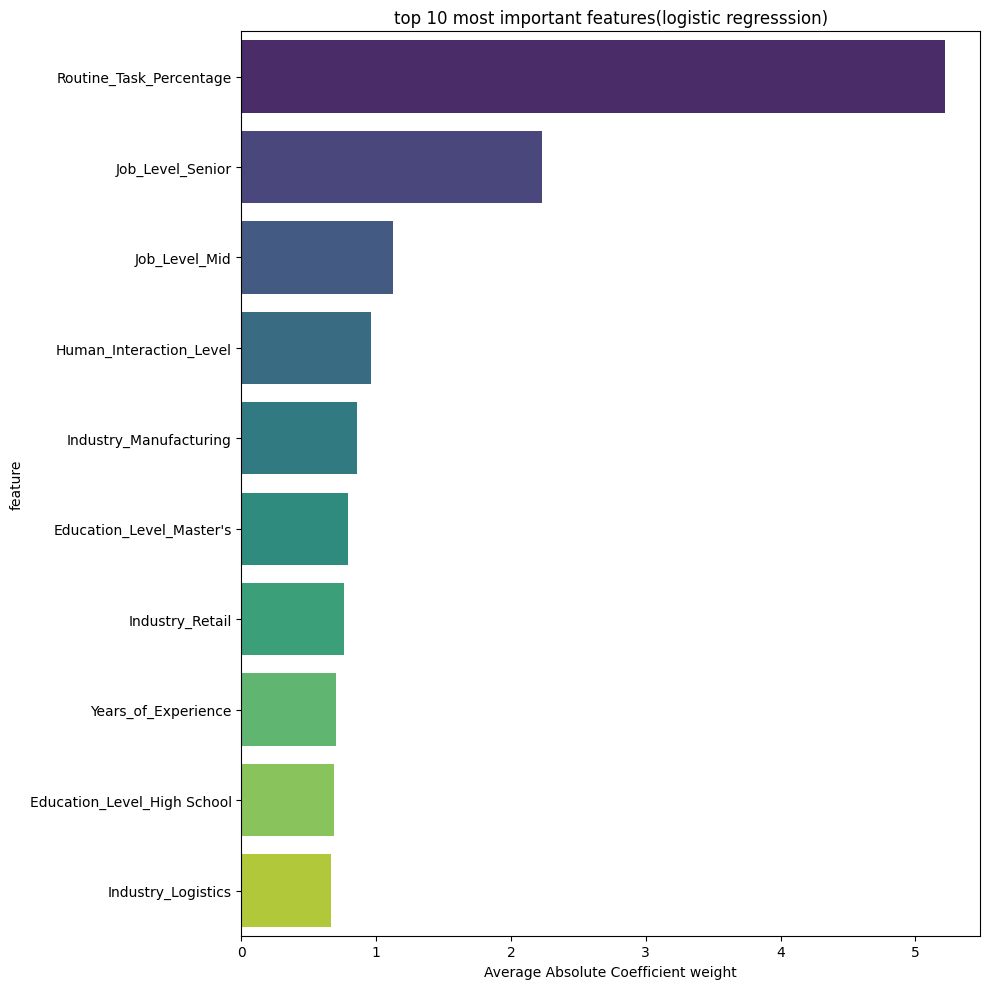

In [23]:
feature_name=X.columns if 'X' in locals() else df_encoded.drop(columns=['Layoff_Risk'],errors='ignore').columns

avg_importance=np.mean(np.abs(model.coef_),axis=0)

importance_df=pd.DataFrame({'Feature':feature_name,'Importance':avg_importance}).sort_values(by='Importance',ascending=False)

plt.figure(figsize=(10,10))
sns.barplot(x='Importance',y='Feature',data=importance_df.head(10),palette='viridis')
plt.title("top 10 most important features(logistic regresssion)")
plt.xlabel('Average Absolute Coefficient weight')
plt.ylabel('feature')
plt.tight_layout()
plt.show()